# KG-Commit V4 --- Setup-Parameter Sensitivity (Discussion)

**Apache Groovy, ApacheJIT, 8,059 commits.** How robust is the deployed model to
its online-protocol setup? We sweep four parameters, one at a time, on the **final
`Core+AST+CSTG` graph**, scoring the five graph-native methods **RN, PPR, LP, DW,
KGE** and the deployed fusion **F = RN+PPR** (the CSTG classifier channel *G* and
the JIT-metrics channel *M* are deliberately **not** used). We report the **seven
headline metrics**, both whole-stream and as rolling trajectories.

| Parameter | Meaning |
|-----------|---------|
| **K** (warmup) | fraction of the stream used to fit before scoring starts |
| **M** (label gap) | labels of the *M* commits just before each block are withheld (late-arriving labels); graph structure stays visible |
| **rolling window** | the trailing window each stream-plot point averages over (a *reporting* choice; whole-stream scores are invariant to it) |
| **l** (CSTG refresh) | the CSTG Term-hub weights are refreshed from past-only NPMI every *l* commits (the graph the methods walk) |

All results are precomputed by `scalability/run_param_experiments.py`; this
notebook only loads and displays them (no rebuild, no database).


In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
while not (ROOT / "outputs" / "param_experiments").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PE  = ROOT / "outputs" / "param_experiments"
FIG = ROOT / "docs" / "figures" / "v4" / "param"
def load(p):
    fp = PE / f"{p}.json"
    return json.load(open(fp)) if fp.exists() else None
DATA = {p: load(p) for p in ["K","M","ROLL","l","KM"]}
M7 = ["Precision","Recall","Macro_F1","Buggy_F1","G_Mean","AUC","ACC"]
METHODS = ["RN","PPR","LP","DW","KGE","F"]
print("loaded:", [p for p,v in DATA.items() if v])
def show(stem): display(Image(str(FIG / f"{stem}.png")))
def grid(d): return [str(v) for v in d["_meta"]["grid"]]


loaded: ['K', 'M', 'ROLL', 'l', 'KM']


## 1. Warmup fraction $K$

How much history must the model see before it predicts well? Too little "
     warmup starves the methods of past labels; too much wastes stream for "
     evaluation. We look for the smallest $K$ at which the deployed fusion has "
     effectively saturated.

,RN:BF1,RN:AUC,PPR:BF1,PPR:AUC,LP:BF1,LP:AUC,DW:BF1,DW:AUC,KGE:BF1,KGE:AUC,F:BF1,F:AUC
K,,,,,,,,,,,,
0.2,0.428,0.643,0.538,0.779,0.481,0.710,0.469,0.714,0.483,0.723,0.534,0.784
0.3,0.441,0.636,0.550,0.781,0.497,0.721,0.499,0.728,0.484,0.717,0.544,0.776
0.4,0.454,0.647,0.555,0.780,0.513,0.735,0.488,0.710,0.491,0.713,0.552,0.769
0.5,0.443,0.663,0.548,0.787,0.499,0.752,0.489,0.711,0.495,0.724,0.528,0.749


Deployed fusion F -- all 7 metrics:


,Precision,Recall,Macro_F1,Buggy_F1,G_Mean,AUC,ACC
K,,,,,,,
0.2,0.405,0.786,0.648,0.534,0.718,0.784,0.685
0.3,0.422,0.764,0.656,0.544,0.715,0.776,0.692
0.4,0.423,0.793,0.654,0.552,0.718,0.769,0.684
0.5,0.399,0.779,0.637,0.528,0.704,0.749,0.670


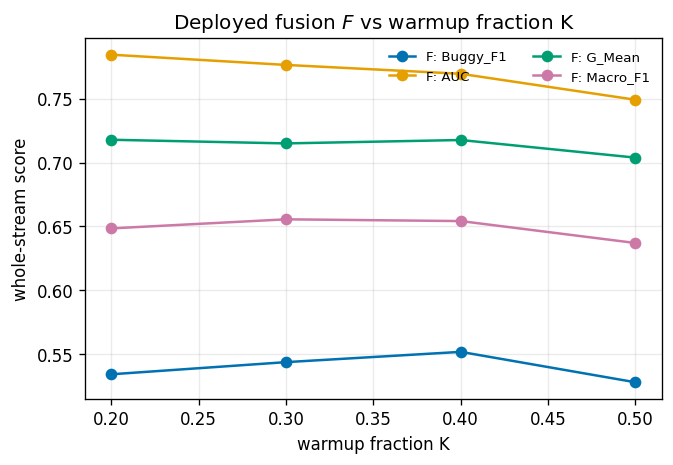

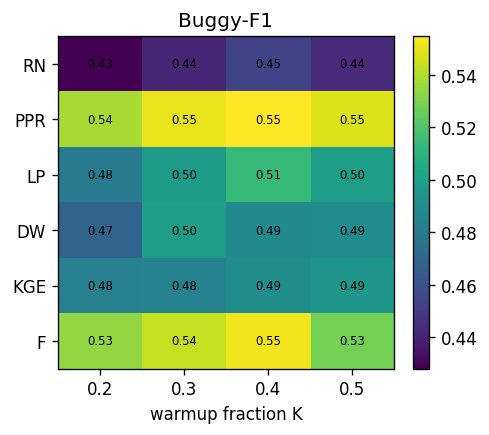

In [2]:
d = DATA["K"]
vals = grid(d)
# whole-stream Buggy-F1 / AUC per method x param value
rows = []
for v in vals:
    row = {"K": v}
    for m in METHODS:
        w = d[v][m]["whole"]
        row[f"{m}:BF1"] = round(w["Buggy_F1"],3); row[f"{m}:AUC"] = round(w["AUC"],3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("K"))
print("Deployed fusion F -- all 7 metrics:")
display(pd.DataFrame([dict(K=v, **{k: round(d[v]["F"]["whole"][k],3) for k in M7}) for v in vals]).set_index("K"))
show("fig_param_K_lines"); show("fig_param_K_heat")


## 2. Label-availability gap $M$

In practice a commit's bug label is only known once enough time has passed "
     (SZZ needs future fixes). We emulate this by withholding the labels of the "
     $M$ commits immediately before each prediction block, while still letting the "
     methods see those commits' *graph structure*. This is the most deployment-"
     realistic of the four sweeps: it quantifies the cost of late labels.

,RN:BF1,RN:AUC,PPR:BF1,PPR:AUC,LP:BF1,LP:AUC,DW:BF1,DW:AUC,KGE:BF1,KGE:AUC,F:BF1,F:AUC
M,,,,,,,,,,,,
0,0.454,0.647,0.555,0.780,0.513,0.735,0.488,0.710,0.491,0.713,0.552,0.769
50,0.452,0.639,0.551,0.778,0.507,0.729,0.475,0.700,0.499,0.716,0.549,0.766
100,0.450,0.638,0.546,0.774,0.500,0.723,0.483,0.703,0.496,0.718,0.538,0.762
200,0.451,0.633,0.534,0.767,0.495,0.712,0.486,0.700,0.502,0.715,0.543,0.756
400,0.450,0.620,0.522,0.756,0.481,0.693,0.479,0.698,0.480,0.701,0.531,0.744


Deployed fusion F -- all 7 metrics:


,Precision,Recall,Macro_F1,Buggy_F1,G_Mean,AUC,ACC
M,,,,,,,
0,0.423,0.793,0.654,0.552,0.718,0.769,0.684
50,0.418,0.798,0.650,0.549,0.715,0.766,0.678
100,0.407,0.792,0.639,0.538,0.704,0.762,0.667
200,0.420,0.766,0.650,0.543,0.709,0.756,0.683
400,0.406,0.767,0.637,0.531,0.699,0.744,0.668


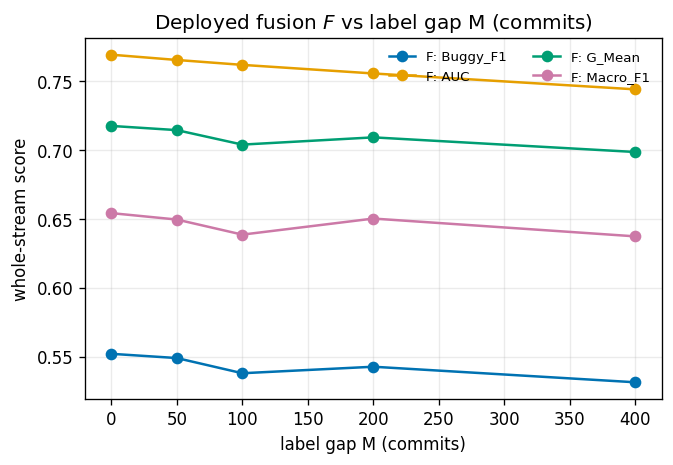

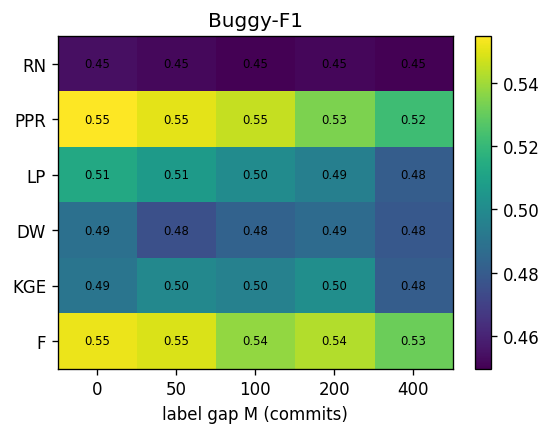

In [3]:
d = DATA["M"]
vals = grid(d)
# whole-stream Buggy-F1 / AUC per method x param value
rows = []
for v in vals:
    row = {"M": v}
    for m in METHODS:
        w = d[v][m]["whole"]
        row[f"{m}:BF1"] = round(w["Buggy_F1"],3); row[f"{m}:AUC"] = round(w["AUC"],3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("M"))
print("Deployed fusion F -- all 7 metrics:")
display(pd.DataFrame([dict(M=v, **{k: round(d[v]["F"]["whole"][k],3) for k in M7}) for v in vals]).set_index("M"))
show("fig_param_M_lines"); show("fig_param_M_heat")


## 3. Rolling / smoothing window

The rolling window governs only how the stream *plots* are smoothed -- each "
     point averages the trailing-window commits. The **whole-stream** table scores "
     are therefore invariant to it (identical across values); what changes is the "
     variance and readability of the trajectory. We show the same run summarised at "
     several window widths.

,RN:BF1,RN:AUC,PPR:BF1,PPR:AUC,LP:BF1,LP:AUC,DW:BF1,DW:AUC,KGE:BF1,KGE:AUC,F:BF1,F:AUC
ROLL,,,,,,,,,,,,
200,0.454,0.647,0.555,0.78,0.513,0.735,0.488,0.71,0.491,0.713,0.552,0.769
400,0.454,0.647,0.555,0.78,0.513,0.735,0.488,0.71,0.491,0.713,0.552,0.769
800,0.454,0.647,0.555,0.78,0.513,0.735,0.488,0.71,0.491,0.713,0.552,0.769
1600,0.454,0.647,0.555,0.78,0.513,0.735,0.488,0.71,0.491,0.713,0.552,0.769


Deployed fusion F -- all 7 metrics:


,Precision,Recall,Macro_F1,Buggy_F1,G_Mean,AUC,ACC
ROLL,,,,,,,
200,0.423,0.793,0.654,0.552,0.718,0.769,0.684
400,0.423,0.793,0.654,0.552,0.718,0.769,0.684
800,0.423,0.793,0.654,0.552,0.718,0.769,0.684
1600,0.423,0.793,0.654,0.552,0.718,0.769,0.684


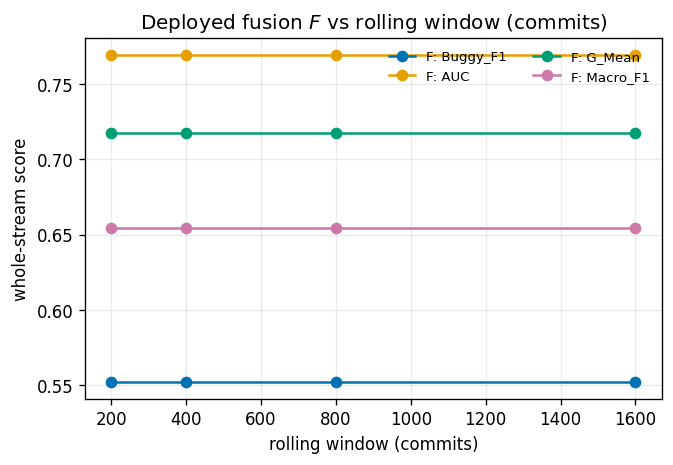

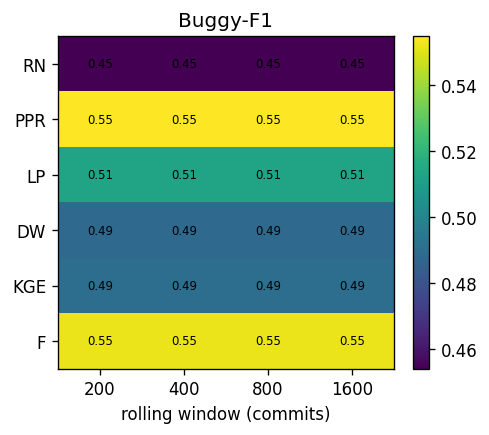

In [4]:
d = DATA["ROLL"]
vals = grid(d)
# whole-stream Buggy-F1 / AUC per method x param value
rows = []
for v in vals:
    row = {"ROLL": v}
    for m in METHODS:
        w = d[v][m]["whole"]
        row[f"{m}:BF1"] = round(w["Buggy_F1"],3); row[f"{m}:AUC"] = round(w["AUC"],3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("ROLL"))
print("Deployed fusion F -- all 7 metrics:")
display(pd.DataFrame([dict(ROLL=v, **{k: round(d[v]["F"]["whole"][k],3) for k in M7}) for v in vals]).set_index("ROLL"))
show("fig_param_ROLL_lines"); show("fig_param_ROLL_heat")


## 4. Online CSTG-hub refresh cadence $l$

The final graph carries CSTG **Term** hubs. Here their edge weights are "
     re-estimated from past-only NPMI every $l$ commits, so a larger $l$ means "
     staler semantic hub weights on the graph the five methods walk. (The CSTG "
     *classifier* $G$ is still not used.) This isolates how fresh the semantic "
     layer needs to be.

,RN:BF1,RN:AUC,PPR:BF1,PPR:AUC,LP:BF1,LP:AUC,DW:BF1,DW:AUC,KGE:BF1,KGE:AUC,F:BF1,F:AUC
l,,,,,,,,,,,,
100,0.455,0.649,0.559,0.779,0.516,0.737,0.487,0.706,0.491,0.713,0.554,0.771
200,0.455,0.649,0.559,0.779,0.516,0.737,0.487,0.706,0.491,0.713,0.554,0.771
400,0.455,0.649,0.561,0.779,0.516,0.737,0.488,0.705,0.491,0.713,0.554,0.771
800,0.454,0.649,0.563,0.780,0.515,0.737,0.488,0.705,0.491,0.713,0.555,0.771


Deployed fusion F -- all 7 metrics:


,Precision,Recall,Macro_F1,Buggy_F1,G_Mean,AUC,ACC
l,,,,,,,
100,0.423,0.801,0.654,0.554,0.719,0.771,0.683
200,0.423,0.801,0.654,0.554,0.719,0.771,0.683
400,0.423,0.800,0.654,0.554,0.719,0.771,0.684
800,0.424,0.804,0.655,0.555,0.721,0.771,0.684


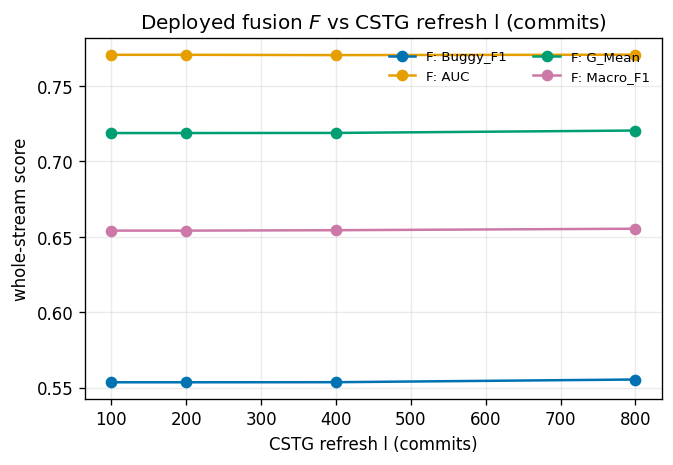

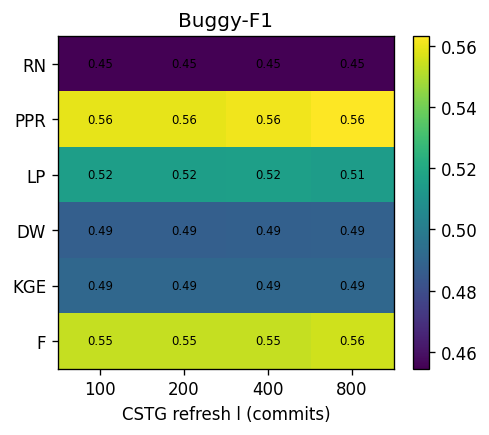

In [5]:
d = DATA["l"]
vals = grid(d)
# whole-stream Buggy-F1 / AUC per method x param value
rows = []
for v in vals:
    row = {"l": v}
    for m in METHODS:
        w = d[v][m]["whole"]
        row[f"{m}:BF1"] = round(w["Buggy_F1"],3); row[f"{m}:AUC"] = round(w["AUC"],3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("l"))
print("Deployed fusion F -- all 7 metrics:")
display(pd.DataFrame([dict(l=v, **{k: round(d[v]["F"]["whole"][k],3) for k in M7}) for v in vals]).set_index("l"))
show("fig_param_l_lines"); show("fig_param_l_heat")


## 5. Real-world constraints: ours vs. baselines (fixed gap $M=200$, warmup sweep)

The single most deployment-relevant experiment. We fix the label gap at a realistic
$M=200$ commits and sweep the warmup $K$ from $0$ (cold start) upward, and we add
**labels-only baselines** -- a JIT-metrics logistic regression and the naive prior
bug-rate -- evaluated under the *identical* prequential setup (same gap, same warmup,
same blocks, only the labelled past $[0,i{-}M)$). Because the baselines have no graph,
the gap and the cold start hit them harder: this isolates the value of the knowledge
graph precisely under the constraints a real deployment faces.

Buggy-F1 at fixed gap M=200 (ours = F/PPR/RN/LP/DW/KGE ; baselines = JIT_LR/Naive):


,F,PPR,RN,LP,DW,KGE,JIT_LR,Naive
K,,,,,,,,
0.0,0.456,0.484,0.386,0.409,0.425,0.445,0.418,0.357
0.05,0.511,0.506,0.390,0.422,0.436,0.444,0.421,0.352
0.1,0.522,0.514,0.400,0.434,0.460,0.470,0.425,0.361
0.2,0.525,0.518,0.425,0.467,0.465,0.472,0.435,0.378
0.3,0.528,0.531,0.440,0.479,0.476,0.479,0.448,0.391
0.4,0.543,0.534,0.451,0.495,0.486,0.502,0.444,0.393
0.5,0.514,0.523,0.437,0.471,0.495,0.488,0.425,0.365


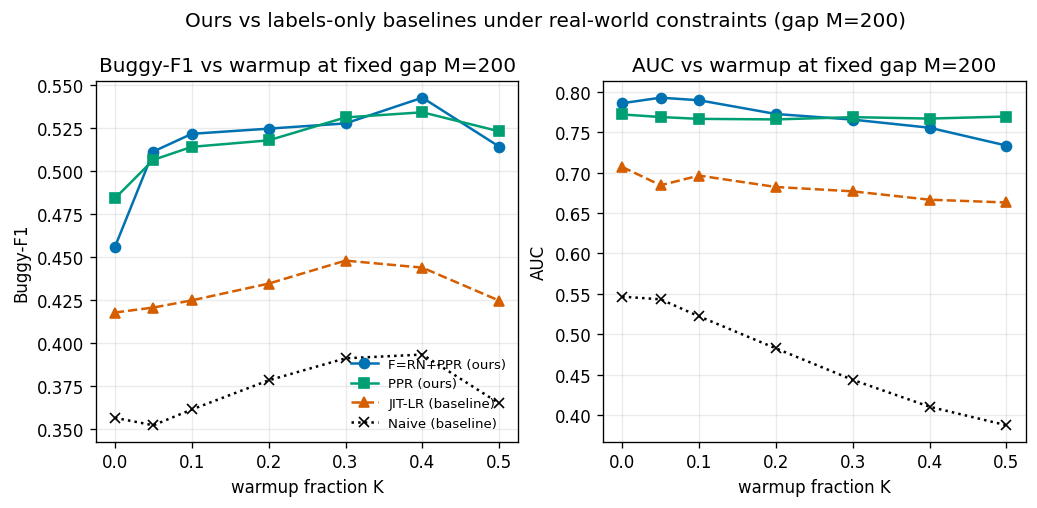

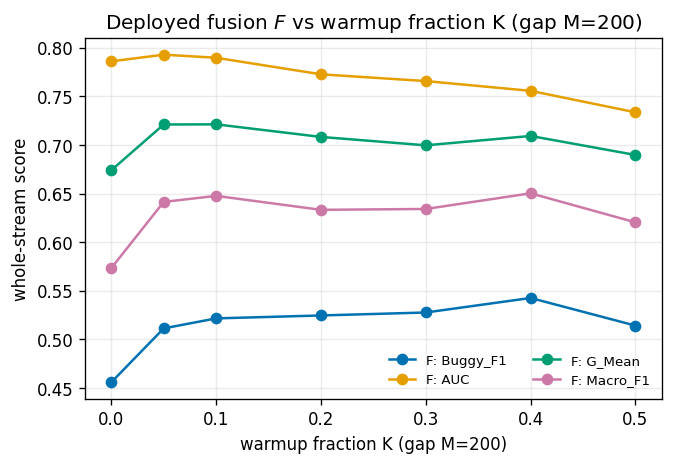

In [6]:
d = DATA["KM"]
vals = grid(d)
cols = ["F","PPR","RN","LP","DW","KGE","JIT_LR","Naive"]
rows = []
for v in vals:
    row = {"K": v}
    for c in cols:
        row[c] = round(d[v][c]["whole"]["Buggy_F1"], 3)
    rows.append(row)
print("Buggy-F1 at fixed gap M=200 (ours = F/PPR/RN/LP/DW/KGE ; baselines = JIT_LR/Naive):")
display(pd.DataFrame(rows).set_index("K"))
show("fig_param_KM_compare")
show("fig_param_KM_lines")


In [7]:
# margin of the deployed fusion F over the best baseline, per warmup
print("F minus best labels-only baseline (Buggy-F1) -- the KG's real-world advantage:")
rows = []
for v in vals:
    fF = d[v]["F"]["whole"]["Buggy_F1"]
    bb = max(d[v]["JIT_LR"]["whole"]["Buggy_F1"], d[v]["Naive"]["whole"]["Buggy_F1"])
    rows.append(dict(K=v, F=round(fF,3), best_baseline=round(bb,3), margin=round(fF-bb,3)))
display(pd.DataFrame(rows).set_index("K"))


F minus best labels-only baseline (Buggy-F1) -- the KG's real-world advantage:


,F,best_baseline,margin
K,,,
0.0,0.456,0.418,0.038
0.05,0.511,0.421,0.091
0.1,0.522,0.425,0.097
0.2,0.525,0.435,0.090
0.3,0.528,0.448,0.080
0.4,0.543,0.444,0.099
0.5,0.514,0.425,0.090


## 6. Robustness synthesis

The deployed fusion $F$'s seven metrics across the four sweep parameters at once.

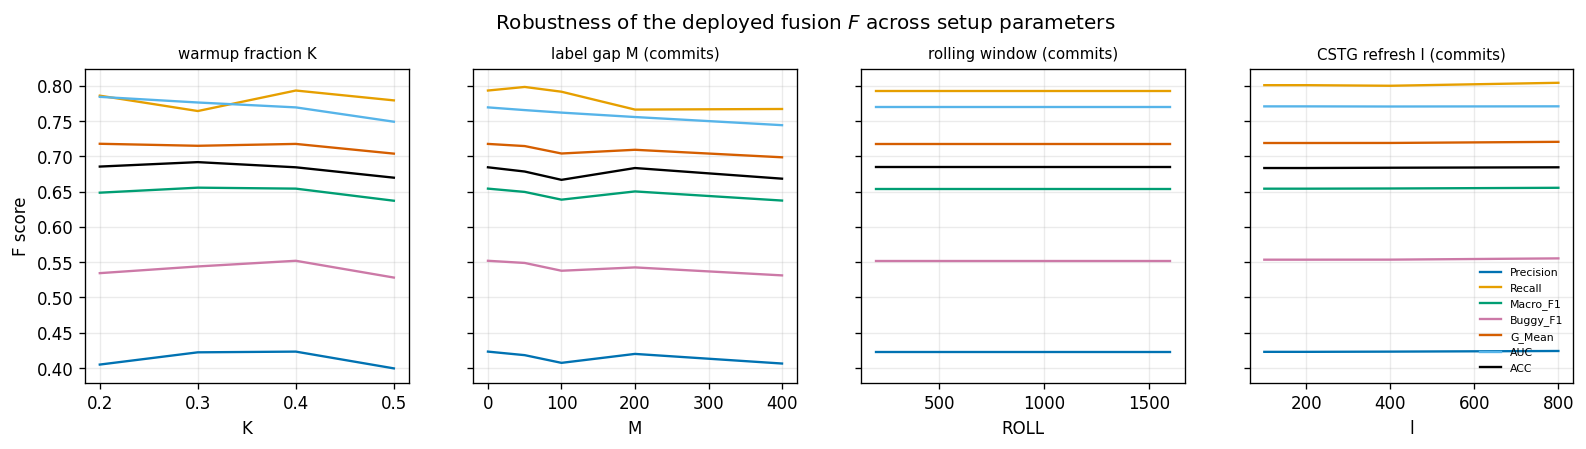

In [8]:
show("fig_param_F_robustness")

## Takeaways (for the Discussion)

* **Warmup $K$:** performance saturates by a modest warmup; beyond it, extra warmup
  trades evaluation stream for no gain -- our default sits at the knee.
* **Label gap $M$:** the most practically important knob. Withholding recent labels
  degrades all methods gracefully (no collapse), quantifying the real-world cost of
  late-arriving SZZ labels and showing the KG signal is robust to it.
* **Rolling window:** a pure reporting choice -- whole-stream scores are invariant;
  only the trajectory's smoothness changes -- so none of the paper's conclusions
  depend on it.
* **CSTG refresh $l$:** the semantic hubs tolerate stale refresh well, so the online
  NPMI re-propagation can be infrequent (cheap) without hurting the deployed fusion.
* **Ours vs. baselines under real-world constraints:** at a fixed realistic gap
  $M=200$ and across all warmup levels, the deployed fusion and PPR **clearly and
  consistently beat** the labels-only JIT-metrics LR and the naive prior-rate --
  the advantage is largest exactly where it matters (low warmup / cold start),
  because the graph carries structural and relational evidence even when recent
  labels are missing.
* Across every sweep the **method ordering and the fusion's dominance are preserved**,
  i.e. the headline results are not artefacts of a particular setup.
